In [ ]:
%pip install timm==0.9.12 torch torchmetrics torchvision --index-url https://download.pytorch.org/whl/cu121 --upgrade tqdm opencv-python pillow --upgrade

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())  # True if GPU can be used
print("Number of GPUs:", torch.cuda.device_count())  # How many GPUs are detected
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))  # Name of the first GPU


CUDA available: True
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4060 Ti


In [ ]:
# Cell 1
from pathlib import Path
import os, re, random, math, shutil, hashlib, cv2
from glob import glob
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
from tqdm import tqdm

# ⚙️ SET YOUR DATA ROOT
DATA_ROOT = Path(r"G:/My Drive/CLPD-MF-Dataset")  
assert DATA_ROOT.exists(), f"Dataset folder not found at {DATA_ROOT}"
print("Found dataset root:", DATA_ROOT)


Found dataset root: G:\My Drive\CLPD-MF-Dataset


In [ ]:
# Cell 2
def infer_magnification_from_name(name):
    m = re.search(r'(\d+)\s*[xX]', name) or re.search(r'[xX]\s*(\d+)', name)
    if m:
        val = int(m.group(1))
        if val in (5,10,20): return f"x{val}"
        if val >= 20: return "x20"
        elif val >= 10: return "x10"
        else: return "x5"
    m2 = re.search(r'\b(5|10|20)\b', name)
    if m2: return f"x{int(m2.group(1))}"
    return None

def list_images_and_labels(root):
    rows=[]
    root = Path(root)
    for label_dir in root.iterdir():
        if not label_dir.is_dir(): continue
        label = label_dir.name
        for img_path in label_dir.rglob('*.tif'):
            patient = img_path.parent.name
            mag = infer_magnification_from_name(img_path.name)
            rows.append({'path': img_path, 'label': label, 'patient': patient, 'mag': mag})
    return rows

all_images = list_images_and_labels(DATA_ROOT)
print("Total images found:", len(all_images))
from collections import Counter
print(Counter([r['mag'] for r in all_images]))


Total images found: 840
Counter({'x20': 531, 'x10': 219, 'x5': 90})


In [ ]:
# Cell 3
PATCH_CACHE = Path('./patch_cache')
PATCH_CACHE.mkdir(exist_ok=True)

def extract_and_cache_patches(img_path, patch_size=512, stride=256, 
                              min_foreground_ratio=0.05, max_patches_per_image=200):
    key = hashlib.sha1(str(img_path).encode()).hexdigest()
    cache_dir = PATCH_CACHE / key
    if cache_dir.exists() and any(cache_dir.iterdir()):
        return sorted([str(p) for p in cache_dir.glob('*.jpg')])

    cache_dir.mkdir(parents=True, exist_ok=True)
    img = Image.open(img_path).convert('RGB')
    W,H = img.size
    patches = []

    for y in range(0, H-patch_size+1, stride):
        for x in range(0, W-patch_size+1, stride):
            crop = img.crop((x,y,x+patch_size,y+patch_size))
            arr = np.asarray(crop)
            v = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            fg_ratio = (v > 10).mean()
            if fg_ratio < min_foreground_ratio: continue
            fname = cache_dir / f'{x}_{y}.jpg'
            crop.save(fname, quality=90)
            patches.append(str(fname))
            if len(patches) >= max_patches_per_image: break
        if len(patches) >= max_patches_per_image: break
    return patches


In [ ]:
# Cell 4
from torch.utils.data import Dataset, DataLoader

class MFHistologyDataset(Dataset):
    def __init__(self, rows, mag='x20', mode='train', patching=True, patch_size=512,
                 stride=256, transforms=None, max_patches_per_image=100):
        self.rows = [r for r in rows if (mag is None or r['mag']==mag)]
        self.mode = mode
        self.patching = patching
        self.patch_size = patch_size
        self.stride = stride
        self.max_patches_per_image = max_patches_per_image
        self.transforms = transforms
        labels = sorted(list({r['label'] for r in rows}))
        self.label2idx = {lab:i for i,lab in enumerate(labels)}

        self.items = []
        for r in self.rows:
            if self.patching:
                patches = extract_and_cache_patches(r['path'], patch_size=self.patch_size,
                                                    stride=self.stride, max_patches_per_image=self.max_patches_per_image)
                for p in patches:
                    self.items.append({'img': p, 'label': self.label2idx[r['label']], 'source': str(r['path'])})
            else:
                self.items.append({'img': str(r['path']), 'label': self.label2idx[r['label']], 'source': str(r['path'])})
        if len(self.items)==0:
            print("Warning: dataset empty for magnification", mag)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it['img']).convert('RGB')
        if self.transforms: img = self.transforms(img)
        return img, it['label'], it['source']


train_tf = transforms.Compose([
    transforms.Resize((384,384), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((384,384), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [ ]:
# Cell 5
def patient_split_three_way(rows, mag='x20', val_frac=0.15, seed=42):
    # group by patient
    by_patient = {}
    for r in rows:
        if mag is not None and r['mag']!=mag: continue
        by_patient.setdefault(r['patient'], []).append(r)
    patients = list(by_patient.keys())
    random.Random(seed).shuffle(patients)
    n_total = len(patients)
    n_val = max(1, int(n_total * val_frac))
    n_test = max(1, int(n_total * test_frac))

    val_patients = set(patients[:n_val])
    test_patients = set(patients[n_val:n_val+n_test])
    
    train_patients = set(patients[n_val+n_test:])

    train_rows, val_rows, test_rows = [], [], []

    for p, rlist in by_patient.items():
        if p in val_patients:
            val_rows += rlist
        elif p in test_patients:
            test_rows += rlist
        else:
            train_rows += rlist

    return train_rows, val_rows, test_rows


# x20
train_rows_20, val_rows_20, test_rows_20 = patient_split_three_way(
    all_images, mag='x20', val_frac=0.15, test_frac=0.15
)

train_ds_20 = MFHistologyDataset(train_rows_20, mag='x20', mode='train', patching=True, transforms=train_tf)
val_ds_20   = MFHistologyDataset(val_rows_20, mag='x20', mode='val', patching=True, transforms=val_tf)
test_ds_20  = MFHistologyDataset(test_rows_20, mag='x20', mode='test', patching=True, transforms=val_tf)

print(len(train_ds_20), len(val_ds_20), len(test_ds_20))

# x10
train_rows_10, val_rows_10, test_rows_10 = patient_split_three_way(
    all_images, mag='x10', val_frac=0.15, test_frac=0.15
)

train_ds_10 = MFHistologyDataset(train_rows_10, mag='x10', mode='train', patching=True, transforms=train_tf)
val_ds_10   = MFHistologyDataset(val_rows_10, mag='x10', mode='val', patching=True, transforms=val_tf)
test_ds_10  = MFHistologyDataset(test_rows_10, mag='x10', mode='test', patching=True, transforms=val_tf)

print(len(train_ds_10), len(val_ds_10), len(test_ds_10))



20844 4644 3186
8100 1458 2268


In [ ]:
# Cell 6
import timm
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast

def create_model(model_name='resnet50', pretrained=True, num_classes=2, dropout=0.2):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    return model

# Choose model_name = 'resnet50' or 'swin_base_patch4_window7_224' (Swin) or tf_efficientnet_b2
model_name_10x = 'swin_base_patch4_window12_384'
model_name_20x = 'swin_base_patch4_window12_384'
device = torch.device('cuda')

# --- Create separate models for x10 and x20 ---
model_10 = create_model(model_name=model_name_10x, pretrained=True, num_classes=2).to(device)
model_20 = create_model(model_name=model_name_20x, pretrained=True, num_classes=2).to(device)

# --- Compute class weights for each dataset separately ---
def get_class_weights(train_ds):
    counts = {}
    for it in train_ds.items:
        counts[it['label']] = counts.get(it['label'], 0) + 1
    total = sum(counts.values())
    weights = [total/counts.get(i,1) for i in range(len(counts))]
    return torch.tensor(weights, dtype=torch.float).to(device)

weights_10 = get_class_weights(train_ds_10)
weights_20 = get_class_weights(train_ds_20)

# --- Loss functions ---
criterion_10 = nn.CrossEntropyLoss(weight=weights_10)
criterion_20 = nn.CrossEntropyLoss(weight=weights_20)

# --- Optimizers ---
optimizer_10 = optim.AdamW(model_10.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_20 = optim.AdamW(model_20.parameters(), lr=1e-4, weight_decay=1e-4)

# --- GradScalers for mixed precision ---
scaler_10 = torch.amp.GradScaler('cuda')
scaler_20 = torch.amp.GradScaler('cuda')


c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mohamed Hazem\.cache\huggingface\hub\models--timm--swin_base_patch4_window

In [ ]:
# Cell 7
from torch.utils.data import DataLoader
import time

# Save Path
save_path = Path("G:/My Drive/CLPD-MF-Dataset/Local Models")

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    for imgs, labels, _src in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss/total, correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = 0
    all_preds=[]
    all_labels=[]
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    acc = correct/total if total>0 else 0
    return running_loss/total if total>0 else 0, acc, torch.cat(all_preds) if all_preds else torch.tensor([]), torch.cat(all_labels) if all_labels else torch.tensor([])

# dataloaders
train_loader_10 = DataLoader(train_ds_10, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader_10   = DataLoader(val_ds_10, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
train_loader_20 = DataLoader(train_ds_20, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader_20   = DataLoader(val_ds_20, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

# Create separate models
model_10 = create_model(model_name=model_name_10x, pretrained=True, num_classes=2).to(device)
model_20 = create_model(model_name=model_name_20x, pretrained=True, num_classes=2).to(device)

# Separate optimizers and scalers
optimizer_10 = optim.AdamW(model_10.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_20 = optim.AdamW(model_20.parameters(), lr=1e-4, weight_decay=1e-4)
scaler_10 = torch.amp.GradScaler('cuda')
scaler_20 = torch.amp.GradScaler('cuda')

# Separate best validation accuracy trackers
best_val_acc_10 = 0.0
best_val_acc_20 = 0.0

EPOCHS = 10

for epoch in range(EPOCHS):
    t0 = time.time()

    # --- Train x10 model ---
    train_loss_10, train_acc_10 = train_one_epoch(model_10, train_loader_10, optimizer_10, criterion_10, device, scaler_10)
    val_loss_10, val_acc_10, _, _ = validate(model_10, val_loader_10, criterion_10, device)

    # --- Train x20 model ---
    train_loss_20, train_acc_20 = train_one_epoch(model_20, train_loader_20, optimizer_20, criterion_20, device, scaler_20)
    val_loss_20, val_acc_20, _, _ = validate(model_20, val_loader_20, criterion_20, device)

    t1 = time.time()
    print(f"Epoch {epoch+1}/{EPOCHS} | x10 train_acc {train_acc_10:.4f} val_acc {val_acc_10:.4f} | "
          f"x20 train_acc {train_acc_20:.4f} val_acc {val_acc_20:.4f} | time {(t1-t0):.1f}s")

    # Save best models
    if val_acc_10 > best_val_acc_10: 
        best_val_acc_10 = val_acc_10
        torch.save(model_10.state_dict(), save_path / f'model_{model_name_10x}_x10.pth')
        print("Saved best x10 model.")
    if val_acc_20 > best_val_acc_20:
        best_val_acc_20 = val_acc_20
        torch.save(model_20.state_dict(), save_path / f'model_{model_name_20x}_x20.pth')
        print("Saved best x20 model.")



C:\Users\Mohamed Hazem\AppData\Local\Temp\ipykernel_7480\2995518074.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/10 | x10 train_acc 0.5706 val_acc 0.9897 | x20 train_acc 0.9035 val_acc 0.9044 | time 1502.0s
Saved best x10 model.
Saved best x20 model.
Epoch 2/10 | x10 train_acc 0.6995 val_acc 0.1591 | x20 train_acc 0.9594 val_acc 0.8646 | time 1493.9s
Epoch 3/10 | x10 train_acc 0.8477 val_acc 0.0466 | x20 train_acc 0.9683 val_acc 0.8450 | time 1449.2s
Epoch 4/10 | x10 train_acc 0.8962 val_acc 0.0295 | x20 train_acc 0.9727 val_acc 0.8439 | time 1410.8s
Epoch 5/10 | x10 train_acc 0.9185 val_acc 0.0418 | x20 train_acc 0.9733 val_acc 0.8081 | time 1418.7s
Epoch 6/10 | x10 train_acc 0.9277 val_acc 0.1728 | x20 train_acc 0.9802 val_acc 0.7586 | time 1454.8s
Epoch 7/10 | x10 train_acc 0.9369 val_acc 0.1317 | x20 train_acc 0.9796 val_acc 0.8775 | time 1453.6s


KeyboardInterrupt: 

In [ ]:
# Cell 8
# --- Load best models ---
model_10.load_state_dict(torch.load(f"G:/My Drive/CLPD-MF-Dataset/Local Models/model_{model_name_10x}_x10.pth"))
model_10.to('cuda')
model_10.eval()
model_20.load_state_dict(torch.load(f"G:/My Drive/CLPD-MF-Dataset/Local Models/model_{model_name_20x}_x20.pth"))
model_20.to('cuda')
model_20.eval()

# --- Prediction per model ---
def predict_image_by_patches(img_path, model, device, patch_size=512, stride=256, transforms=val_tf):
    """
    Predicts class for one image by extracting patches.
    Returns mean probability and predicted class.
    """
    patches = extract_and_cache_patches(img_path, patch_size=patch_size, stride=stride, max_patches_per_image=200)
    if len(patches) == 0:
        return None
    probs = []
    with torch.no_grad():
        for p in patches:
            x = transforms(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
            out = model(x)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
            probs.append(prob)
    mean_prob = np.array(probs).mean(axis=0)
    pred_class = mean_prob.argmax()
    return {'pred': int(pred_class), 'prob': mean_prob.tolist(), 'num_patches': len(patches)}

# --- Combined prediction for x10 + x20 ---
def combined_prediction(img_paths_dict, model_10, model_20, device):
    """
    img_paths_dict: {'x10': Path(...), 'x20': Path(...)}
    Returns combined probability and predicted class.
    """
    probs = []
    if 'x10' in img_paths_dict:
        res10 = predict_image_by_patches(img_paths_dict['x10'], model_10, device)
        if res10:
            probs.append(res10['prob'])
    if 'x20' in img_paths_dict:
        res20 = predict_image_by_patches(img_paths_dict['x20'], model_20, device)
        if res20:
            probs.append(res20['prob'])
    if len(probs) == 0:
        return None
    combined_prob = np.mean(probs, axis=0)
    combined_class = combined_prob.argmax()
    return {'pred': int(combined_class), 'prob': combined_prob.tolist()}

# --- Example usage ---
example_imgs = {
    'x10': Path("G:/My Drive/CLPD-MF-Dataset/MF/doaa sayed 113-7-21/113-7-21 x10 B tif.tif"),
    'x20': Path("G:/My Drive/CLPD-MF-Dataset/MF/doaa sayed 113-7-21/113-7-21 x20 H .tif")
}
res = combined_prediction(example_imgs, model_10, model_20, device)
label_map = {0: "MF", 1: "Non-MF"}
print(f"Combined prediction: {label_map[res['pred']]} " 
       f"({res['prob'][res['pred']]*100:.1f}% confidence)")

NameError: name 'model_10' is not defined


===== X10 Model Metrics =====
              precision    recall  f1-score   support

      Non-MF       1.00      0.99      0.99      1458
          MF       0.00      0.00      0.00         0

    accuracy                           0.99      1458
   macro avg       0.50      0.49      0.50      1458
weighted avg       1.00      0.99      0.99      1458



c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


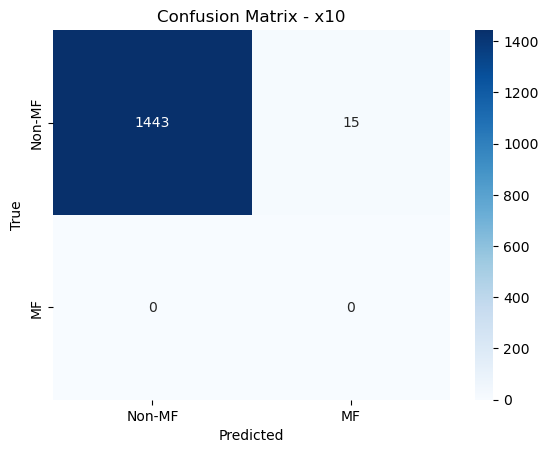


===== X20 Model Metrics =====
              precision    recall  f1-score   support

      Non-MF       0.91      0.97      0.94      3564
          MF       0.89      0.67      0.77      1080

    accuracy                           0.90      4644
   macro avg       0.90      0.82      0.85      4644
weighted avg       0.90      0.90      0.90      4644



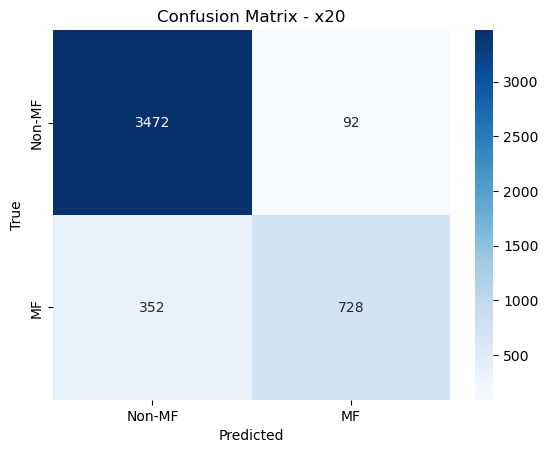

In [ ]:
# CELL 9: 
# Classification Report + Confusion Matrix 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_split(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:,1]   # probability of MF class

            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    return (torch.cat(all_labels).numpy(),
            torch.cat(all_preds).numpy(),
            torch.cat(all_probs).numpy())

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-MF", "MF"],
                yticklabels=["Non-MF", "MF"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ---- Evaluate both models on validation ----
y_true_10, y_pred_10, y_prob_10 = evaluate_split(model_10, val_loader_10, device)
y_true_20, y_pred_20, y_prob_20 = evaluate_split(model_20, val_loader_20, device)

# ---- Print Text Reports ----
print("\n===== X10 Model Metrics =====")
print(classification_report(y_true_10, y_pred_10, target_names=["Non-MF","MF"]))
plot_confusion_matrix(y_true_10, y_pred_10, "Confusion Matrix - x10")

print("\n===== X20 Model Metrics =====")
print(classification_report(y_true_20, y_pred_20, target_names=["Non-MF","MF"]))
plot_confusion_matrix(y_true_20, y_pred_20, "Confusion Matrix - x20")


In [ ]:
# CELL 10
# ROC Curve 

from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(y_true_10, y_prob_10, "ROC Curve - x10 Model")
plot_roc_curve(y_true_20, y_prob_20, "ROC Curve - x20 Model")


NameError: name 'y_true_10' is not defined

In [ ]:
# CELL 11: 
# Precision–Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(y_true, y_prob, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP = {ap:.3f})")
    plt.show()

plot_pr_curve(y_true_10, y_prob_10, "Precision-Recall Curve - x10")
plot_pr_curve(y_true_20, y_prob_20, "Precision-Recall Curve - x20")
